# OpenFOAM Results Plotting

This notebook plots the finished OpenFOAM lid-driven cavity results using a style similar to `start-code/phase1_plotting.ipynb`. It reads the final OpenFOAM field files, creates `u`, `v`, and pressure contour plots, and plots vertical centerline velocity and pressure profiles for comparison with the Python solver.

The pressure plot applies a constant offset so the OpenFOAM center pressure matches the course reference pressure, `p_ref = 0.8013338444662 N/m^2`.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np

case_dir = Path.cwd()
if not (case_dir / 'system').exists():
    # Allows the notebook to run from the repository root too.
    case_dir = Path('openfoam-cavity-Re100')

plot_dir = case_dir / 'OpenFOAM Plots'
plot_dir.mkdir(exist_ok=True)

L = 0.05
nx = 64
ny = 64
rho = 1.0
u_lid = 1.0
reynolds_number = 100
p_ref_course = 0.8013338444662

numeric_times = sorted(
    [p for p in case_dir.iterdir() if p.is_dir() and re.fullmatch(r'\d+(\.\d+)?', p.name)],
    key=lambda p: float(p.name),
)
latest_time = numeric_times[-1]
print(f'Using OpenFOAM case: {case_dir.resolve()}')
print(f'Using latest time directory: {latest_time.name}')
print(f'Saving plots to: {plot_dir.resolve()}')

Using OpenFOAM case: /Users/windy/mae4100-courseproject2/openfoam-cavity-Re100
Using latest time directory: 1952
Saving plots to: /Users/windy/mae4100-courseproject2/openfoam-cavity-Re100/OpenFOAM Plots


## Read OpenFOAM Fields

OpenFOAM stores the final fields in the latest numeric time directory. The helper functions below parse the internal cell-centered `U` and `p` data and reshape it onto the `64 x 64` cavity mesh.

In [2]:
def _internal_field_block(path):
    text = path.read_text()
    match = re.search(r'internalField\s+nonuniform\s+List<[^>]+>\s+\d+\s*\(\s*(.*?)\s*\)\s*;', text, re.S)
    if match is None:
        raise ValueError(f'Could not find a nonuniform internalField in {path}')
    return match.group(1)


def read_scalar_field(path, nx, ny):
    block = _internal_field_block(path)
    values = np.fromstring(block, sep=' ')
    if values.size != nx * ny:
        raise ValueError(f'Expected {nx * ny} scalar values in {path}, found {values.size}')
    return values.reshape((ny, nx))


def read_vector_field(path, nx, ny):
    block = _internal_field_block(path)
    clean = block.replace('(', ' ').replace(')', ' ')
    values = np.fromstring(clean, sep=' ')
    if values.size != nx * ny * 3:
        raise ValueError(f'Expected {nx * ny * 3} vector values in {path}, found {values.size}')
    return values.reshape((ny, nx, 3))


U = read_vector_field(latest_time / 'U', nx, ny)
p = read_scalar_field(latest_time / 'p', nx, ny)

x = (np.arange(nx) + 0.5) * L / nx
y = (np.arange(ny) + 0.5) * L / ny
X, Y = np.meshgrid(x, y)

u = U[:, :, 0]
v = U[:, :, 1]

print(f'U shape: {U.shape}')
print(f'p shape: {p.shape}')
print(f'u range: {u.min():.6g} to {u.max():.6g}')
print(f'v range: {v.min():.6g} to {v.max():.6g}')
print(f'p range before offset: {p.min():.6g} to {p.max():.6g}')

U shape: (64, 64, 3)
p shape: (64, 64)
u range: -0.242615 to 0.952215
v range: -0.530198 to 0.285677
p range before offset: -1.42492 to 2.17067


## Pressure Reference

The course solver fixes the center pressure at `0.8013338444662 N/m^2`. OpenFOAM pressure is only determined up to a constant, so this cell computes and applies a constant pressure offset using the sampled vertical centerline value at `x = 0.5L`, `y = 0.5L`.

In [3]:
sample_dir = case_dir / 'postProcessing' / 'sampleDict' / latest_time.name
vertical_path = sample_dir / 'verticalCenterline.xy'
horizontal_path = sample_dir / 'horizontalCenterline.xy'

vertical = np.loadtxt(vertical_path, comments='#')
horizontal = np.loadtxt(horizontal_path, comments='#')

# Column order: x, y, z, U_x, U_y, U_z, p
center_idx = np.argmin(np.abs(vertical[:, 1] - 0.5 * L))
p_center_openfoam = vertical[center_idx, 6]
p_offset = p_ref_course - p_center_openfoam
p_course_ref = p + p_offset
vertical_ref = vertical.copy()
horizontal_ref = horizontal.copy()
vertical_ref[:, 6] += p_offset
horizontal_ref[:, 6] += p_offset

print(f'OpenFOAM center pressure: {p_center_openfoam:.12g}')
print(f'Course reference pressure: {p_ref_course:.12g}')
print(f'Applied pressure offset: {p_offset:.12g}')
print(f'p range after offset: {p_course_ref.min():.6g} to {p_course_ref.max():.6g}')

OpenFOAM center pressure: -0.0369824698
Course reference pressure: 0.801333844466
Applied pressure offset: 0.838316314266
p range after offset: -0.586601 to 3.00899


## Contour Plots

These figures mirror the Phase I contour outputs: `u`, `v`, and pressure contours saved as PNG files.

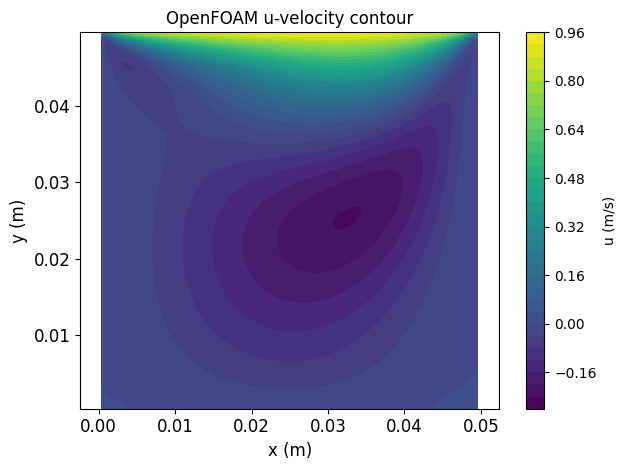

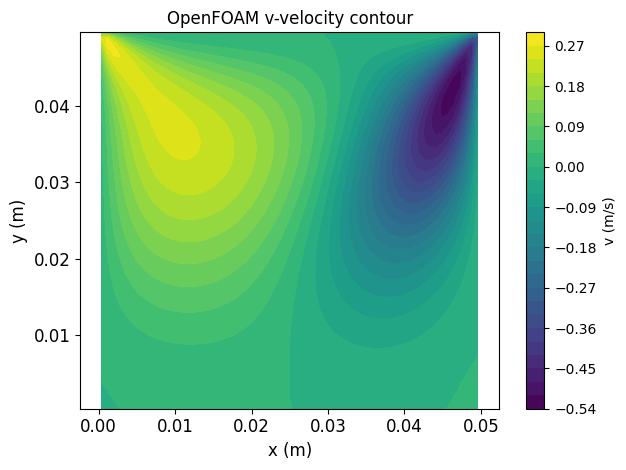

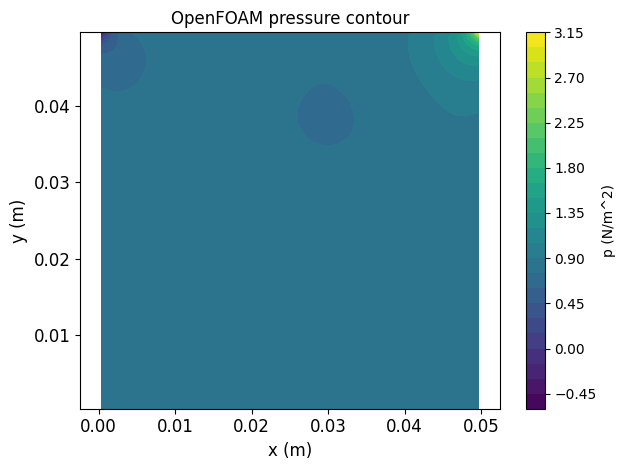

In [4]:
fontsize = 12
levels = 31


def save_contour(field, title, colorbar_label, filename):
    plt.figure(figsize=(6.4, 4.8))
    contour = plt.contourf(X, Y, field, levels=levels, cmap='viridis')
    plt.colorbar(contour, label=colorbar_label)
    plt.xlabel('x (m)', fontsize=fontsize)
    plt.ylabel('y (m)', fontsize=fontsize)
    plt.title(title, fontsize=fontsize)
    plt.axis('equal')
    plt.xticks(fontsize=fontsize)
    plt.yticks(fontsize=fontsize)
    plt.tight_layout()
    plt.savefig(plot_dir / filename, dpi=300)
    plt.show()


save_contour(u, 'OpenFOAM u-velocity contour', 'u (m/s)', 'openfoam_ucontour.png')
save_contour(v, 'OpenFOAM v-velocity contour', 'v (m/s)', 'openfoam_vcontour.png')
save_contour(p_course_ref, 'OpenFOAM pressure contour', 'p (N/m^2)', 'openfoam_pcontour.png')

## Vertical Centerline Profiles

The course project asks for velocity and pressure profiles along the vertical centerline. These use the OpenFOAM sampled line at `x = 0.5L`.

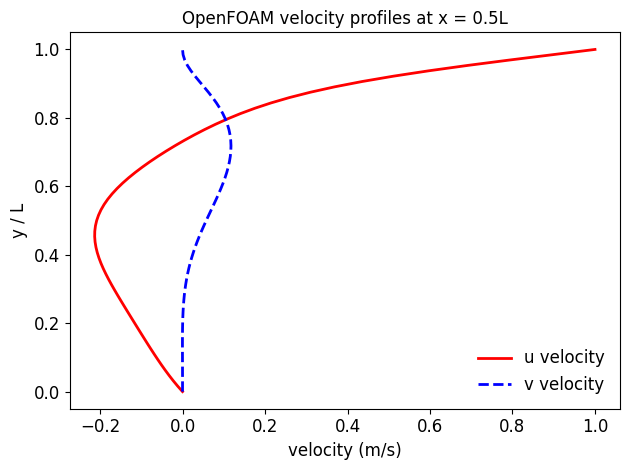

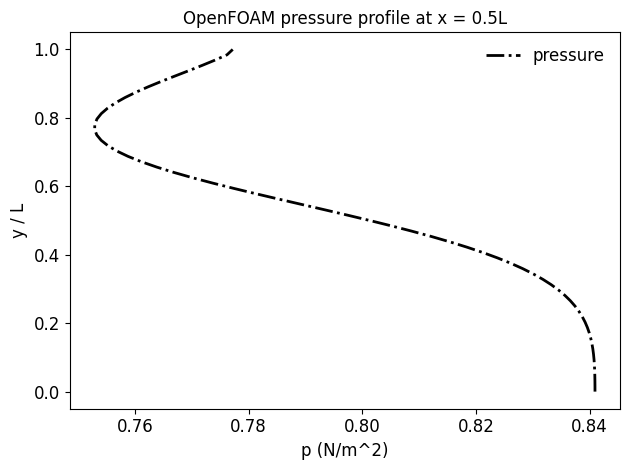

In [5]:
y_profile = vertical[:, 1] / L
u_centerline = vertical[:, 3]
v_centerline = vertical[:, 4]
p_centerline = vertical_ref[:, 6]

plt.figure(figsize=(6.4, 4.8))
plt.plot(u_centerline, y_profile, '-r', linewidth=2, label='u velocity')
plt.plot(v_centerline, y_profile, '--b', linewidth=2, label='v velocity')
plt.xlabel('velocity (m/s)', fontsize=fontsize)
plt.ylabel('y / L', fontsize=fontsize)
plt.title('OpenFOAM velocity profiles at x = 0.5L', fontsize=fontsize)
plt.legend(loc='best', fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig(plot_dir / 'openfoam_velocity_centerline_profiles.png', dpi=300)
plt.show()

plt.figure(figsize=(6.4, 4.8))
plt.plot(p_centerline, y_profile, '-.k', linewidth=2, label='pressure')
plt.xlabel('p (N/m^2)', fontsize=fontsize)
plt.ylabel('y / L', fontsize=fontsize)
plt.title('OpenFOAM pressure profile at x = 0.5L', fontsize=fontsize)
plt.legend(loc='best', fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig(plot_dir / 'openfoam_pressure_centerline_profile.png', dpi=300)
plt.show()

## Optional Horizontal Centerline Profiles

The final report/literature comparison often uses the horizontal centerline too, so this cell saves an extra profile figure from `y = 0.5L`.

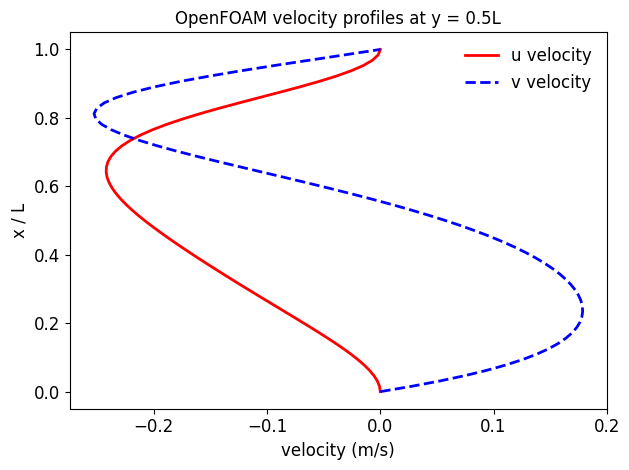

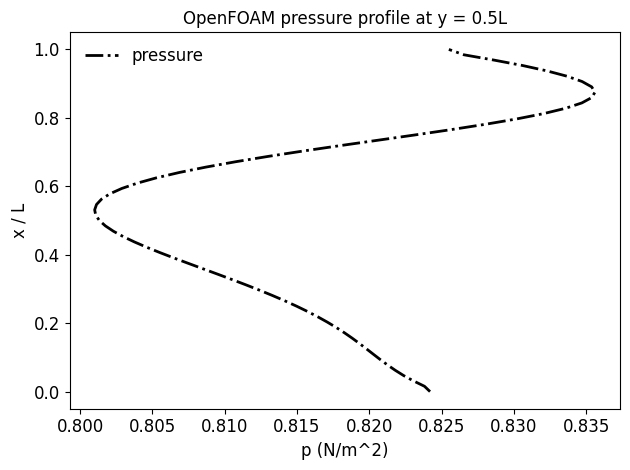

In [6]:
x_profile = horizontal[:, 0] / L
u_horizontal = horizontal[:, 3]
v_horizontal = horizontal[:, 4]
p_horizontal = horizontal_ref[:, 6]

plt.figure(figsize=(6.4, 4.8))
plt.plot(u_horizontal, x_profile, '-r', linewidth=2, label='u velocity')
plt.plot(v_horizontal, x_profile, '--b', linewidth=2, label='v velocity')
plt.xlabel('velocity (m/s)', fontsize=fontsize)
plt.ylabel('x / L', fontsize=fontsize)
plt.title('OpenFOAM velocity profiles at y = 0.5L', fontsize=fontsize)
plt.legend(loc='best', fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig(plot_dir / 'openfoam_horizontal_velocity_centerline_profiles.png', dpi=300)
plt.show()

plt.figure(figsize=(6.4, 4.8))
plt.plot(p_horizontal, x_profile, '-.k', linewidth=2, label='pressure')
plt.xlabel('p (N/m^2)', fontsize=fontsize)
plt.ylabel('x / L', fontsize=fontsize)
plt.title('OpenFOAM pressure profile at y = 0.5L', fontsize=fontsize)
plt.legend(loc='best', fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig(plot_dir / 'openfoam_horizontal_pressure_centerline_profile.png', dpi=300)
plt.show()